In [1]:
!pip install pandas matplotlib seaborn scikit-learn

First 5 Rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Dataset Description
   

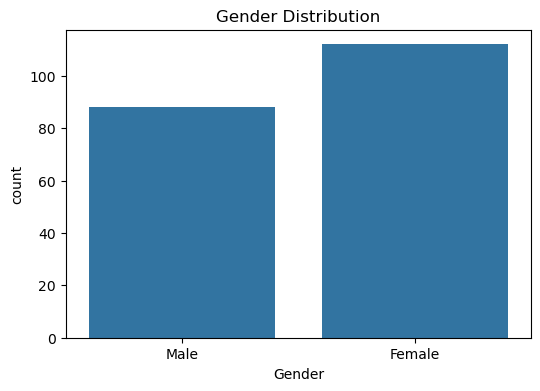

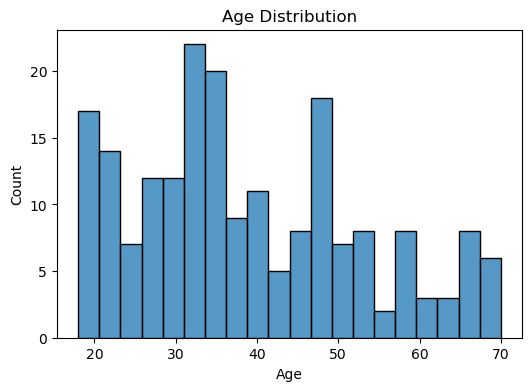

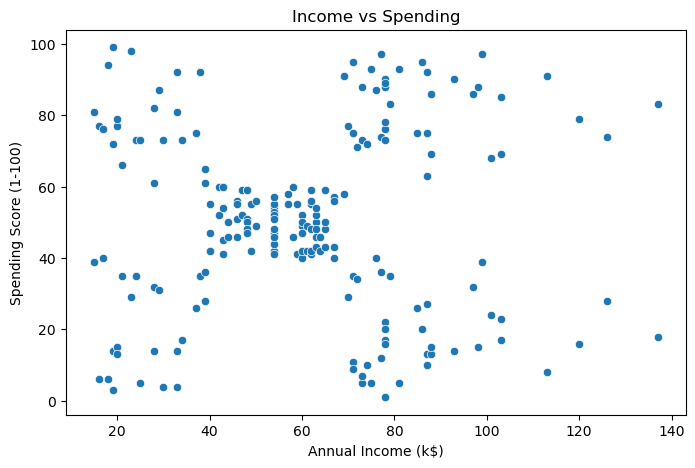

C:\Users\91812\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\91812\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\91812\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\91812\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

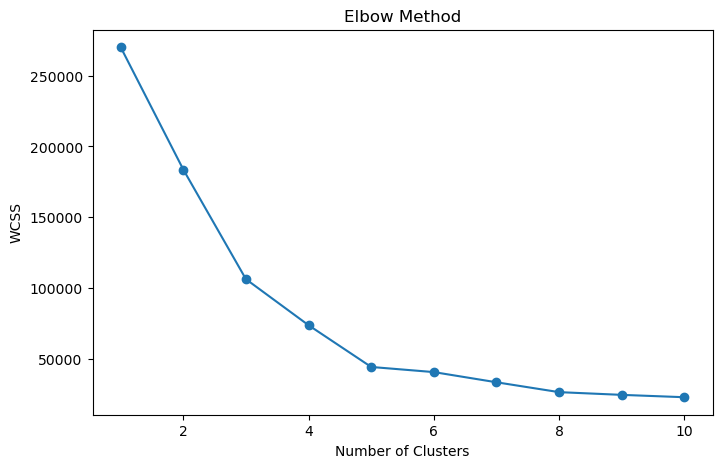

C:\Users\91812\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


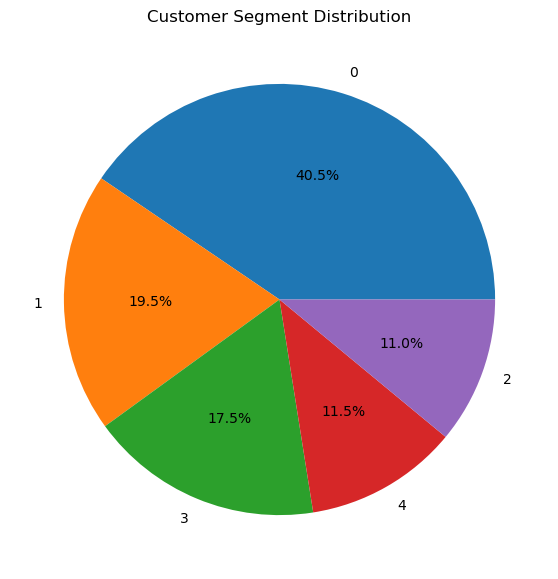

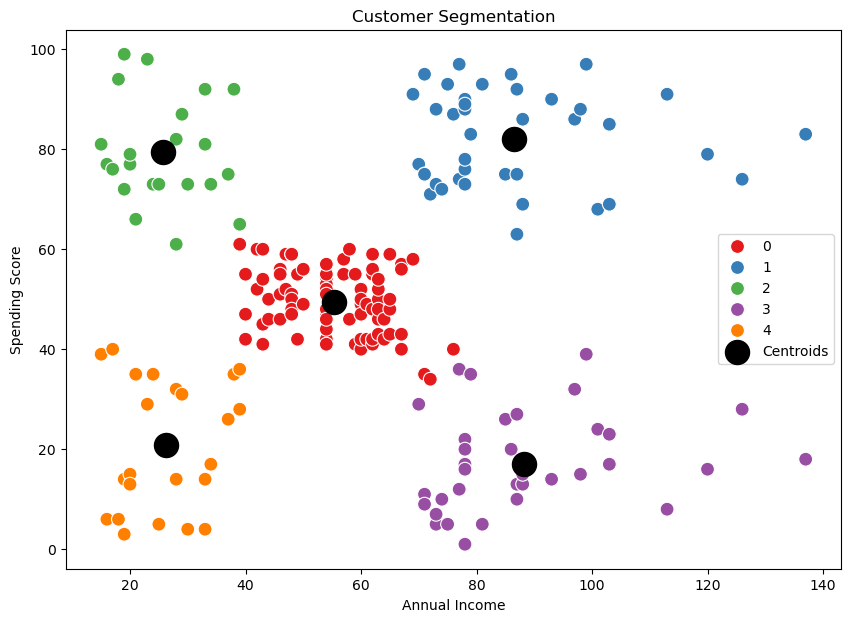


Cluster Analysis
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043

Project Completed Successfully
Output file saved as Customer_Segments_Output.csv


In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Step 1 - Load Dataset
df = pd.read_csv("Mall_Customers.csv")

print("First 5 Rows")
print(df.head())

# Step 2 - Dataset Information
print("\nDataset Info")
print(df.info())

print("\nDataset Description")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# ================================
# DATA VISUALIZATION
# ================================

# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

# Income vs Spending
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending")
plt.show()

# ================================
# FEATURE SELECTION
# ================================

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ================================
# ELBOW METHOD
# ================================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# ================================
# K-MEANS CLUSTERING
# ================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans

# ================================
# PIE CHART
# ================================

cluster_counts = df['Cluster'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%'
)

plt.title("Customer Segment Distribution")

plt.show()

# ================================
# CLUSTER VISUALIZATION
# ================================

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    label='Centroids'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.legend()

plt.show()

# ================================
# CLUSTER ANALYSIS
# ================================

print("\nCluster Analysis")

print(df.groupby('Cluster').mean(numeric_only=True))

# ================================
# SAVE OUTPUT
# ================================

df.to_csv(
    "Customer_Segments_Output.csv",
    index=False
)

print("\nProject Completed Successfully")
print("Output file saved as Customer_Segments_Output.csv")